In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nilesh2042/air-traffic-passenger-trends-usa-20052024")

100%|██████████| 321k/321k [00:00<00:00, 493kB/s]

Extracting files...


In [2]:
import os

# List the contents of the downloaded directory
print(f"Contents of the downloaded dataset directory ({path}):")
for root, dirs, files in os.walk(path):
    for name in files:
        print(os.path.join(root, name))

Contents of the downloaded dataset directory (/root/.cache/kagglehub/datasets/nilesh2042/air-traffic-passenger-trends-usa-20052024/versions/1):
/root/.cache/kagglehub/datasets/nilesh2042/air-traffic-passenger-trends-usa-20052024/versions/1/Air_Traffic_Passenger_Statistics.csv


Based on the file list, it appears that the main dataset is likely `Air_Traffic_Passenger_Trends_USA_(2005-2024).csv`. I will load this into a pandas DataFrame and display its structure.

In [3]:
import pandas as pd

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'Air_Traffic_Passenger_Statistics.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the DataFrame information (columns, data types, non-null counts)
print("DataFrame Info:")
df.info()

# Display the first 5 rows of the DataFrame
print("\nFirst 5 rows of the DataFrame:")
display(df.head())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38196 entries, 0 to 38195
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Activity Period              38196 non-null  int64 
 1   Activity Period Start Date   38196 non-null  object
 2   Operating Airline            38196 non-null  object
 3   Operating Airline IATA Code  37880 non-null  object
 4   Published Airline            38196 non-null  object
 5   Published Airline IATA Code  37880 non-null  object
 6   GEO Summary                  38196 non-null  object
 7   GEO Region                   38196 non-null  object
 8   Activity Type Code           38196 non-null  object
 9   Price Category Code          38196 non-null  object
 10  Terminal                     38196 non-null  object
 11  Boarding Area                38196 non-null  object
 12  Passenger Count              38196 non-null  int64 
 13  data_as_of     

,Activity Period,Activity Period Start Date,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,data_as_of,data_loaded_at
0,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,31432,2025/06/20 01:00:30 PM,2025/07/20 03:02:25 PM
1,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,31353,2025/06/20 01:00:30 PM,2025/07/20 03:02:25 PM
2,199907,1999/07/01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,2518,2025/06/20 01:00:30 PM,2025/07/20 03:02:25 PM
3,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Deplaned,Other,Terminal 2,D,1324,2025/06/20 01:00:30 PM,2025/07/20 03:02:25 PM
4,199907,1999/07/01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Enplaned,Other,Terminal 2,D,1198,2025/06/20 01:00:30 PM,2025/07/20 03:02:25 PM


In [4]:
# Convert 'Activity Period Start Date' to datetime objects
df['Activity Period Start Date'] = pd.to_datetime(df['Activity Period Start Date'])

# Extract Month and Quarter
df['Month'] = df['Activity Period Start Date'].dt.month
df['Quarter'] = df['Activity Period Start Date'].dt.quarter

# Create 'Is_Summer_Peak' feature (June, July, August)
df['Is_Summer_Peak'] = df['Month'].isin([6, 7, 8])

print("DataFrame after adding time-based features:")
display(df.head())

DataFrame after adding time-based features:


,Activity Period,Activity Period Start Date,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,data_as_of,data_loaded_at,Month,Quarter,Is_Summer_Peak
0,199907,1999-07-01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,31432,2025/06/20 01:00:30 PM,2025/07/20 03:02:25 PM,7,3,True
1,199907,1999-07-01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,31353,2025/06/20 01:00:30 PM,2025/07/20 03:02:25 PM,7,3,True
2,199907,1999-07-01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,2518,2025/06/20 01:00:30 PM,2025/07/20 03:02:25 PM,7,3,True
3,199907,1999-07-01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Deplaned,Other,Terminal 2,D,1324,2025/06/20 01:00:30 PM,2025/07/20 03:02:25 PM,7,3,True
4,199907,1999-07-01,Aeroflot Russian International Airlines,NaN,Aeroflot Russian International Airlines,NaN,International,Europe,Enplaned,Other,Terminal 2,D,1198,2025/06/20 01:00:30 PM,2025/07/20 03:02:25 PM,7,3,True


### Step A: Fit a Prophet model on the global monthly Passenger Count. Include US Federal Holidays as built-in regressors.

Prophet Forecast Components:


,ds,yhat,yhat_lower,yhat_upper
0,1999-07-01,3.132251e+06,2.140630e+06,4.210849e+06
1,1999-08-01,3.130451e+06,2.080534e+06,4.202595e+06
2,1999-09-01,2.690577e+06,1.682203e+06,3.822068e+06
3,1999-10-01,2.796525e+06,1.742698e+06,3.841541e+06
4,1999-11-01,2.583640e+06,1.488824e+06,3.650966e+06


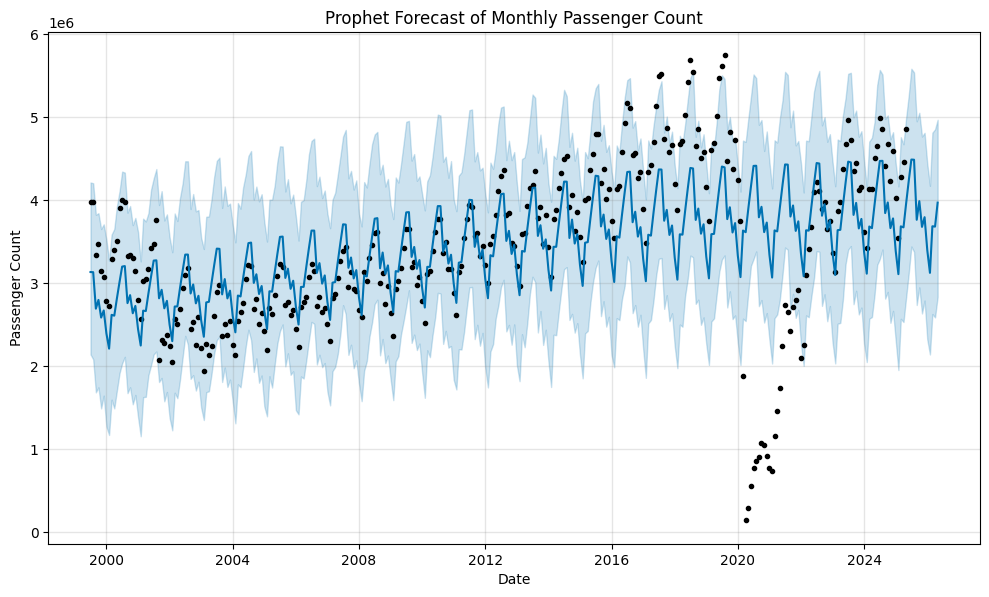

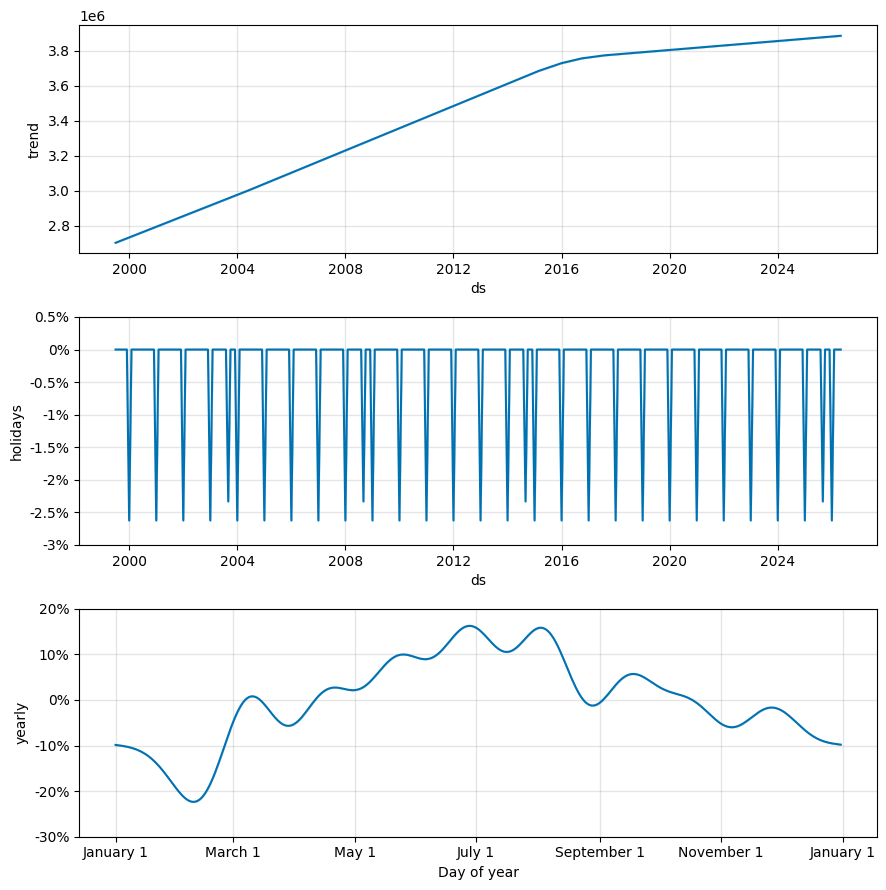

In [6]:
from prophet import Prophet
import holidays # Import the holidays library
import pandas as pd # Ensure pandas is imported
import matplotlib.pyplot as plt # Import matplotlib for plotting

# Aggregate Passenger Count by Activity Period Start Date (monthly time series)
monthly_demand = df.groupby('Activity Period Start Date')['Passenger Count'].sum().reset_index()
monthly_demand = monthly_demand.set_index('Activity Period Start Date').sort_index()

# Prepare data for Prophet: Prophet expects columns named 'ds' and 'y'
prophet_df = monthly_demand.reset_index()[['Activity Period Start Date', 'Passenger Count']]
prophet_df.columns = ['ds', 'y']

# Define US federal holidays
us_holidays = holidays.US(years=range(prophet_df['ds'].min().year, prophet_df['ds'].max().year + 2))

# Convert holidays to a DataFrame format compatible with Prophet
holidays_df = pd.DataFrame(list(us_holidays.items()), columns=['ds', 'holiday'])
holidays_df['ds'] = pd.to_datetime(holidays_df['ds'])

# Initialize Prophet model with seasonality and holidays
m = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# Add US holidays to the model
m.add_country_holidays(country_name='US')

# Fit the Prophet model
m.fit(prophet_df)

# Create a future DataFrame for predictions
future = m.make_future_dataframe(periods=12, freq='MS') # Forecast 12 months into the future

# Make predictions with Prophet
forecast = m.predict(future)

# Display the forecast components
print("Prophet Forecast Components:")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

# Plot the Prophet forecast
fig1 = m.plot(forecast)
plt.title('Prophet Forecast of Monthly Passenger Count')
plt.xlabel('Date')
plt.ylabel('Passenger Count')
plt.show()

# Plot the Prophet forecast components
fig2 = m.plot_components(forecast)
plt.show()

### Step B: Extract the residuals (the errors) from Prophet.

Prophet Model Residuals (first 15 rows):


,ds,y,yhat,residuals
0,1999-07-01,3976746,3.132251e+06,844495.353967
1,1999-08-01,3972694,3.130451e+06,842243.044940
2,1999-09-01,3341964,2.690577e+06,651386.822416
3,1999-10-01,3468846,2.796525e+06,672321.123401
4,1999-11-01,3145240,2.583640e+06,561600.283634
5,1999-12-01,3077142,2.669231e+06,407911.410269
6,2000-01-01,2781129,2.392044e+06,389084.632133
7,2000-02-01,2725393,2.209414e+06,515978.530768
8,2000-03-01,3294029,2.616554e+06,677474.525229
9,2000-04-01,3392617,2.606740e+06,785877.009856


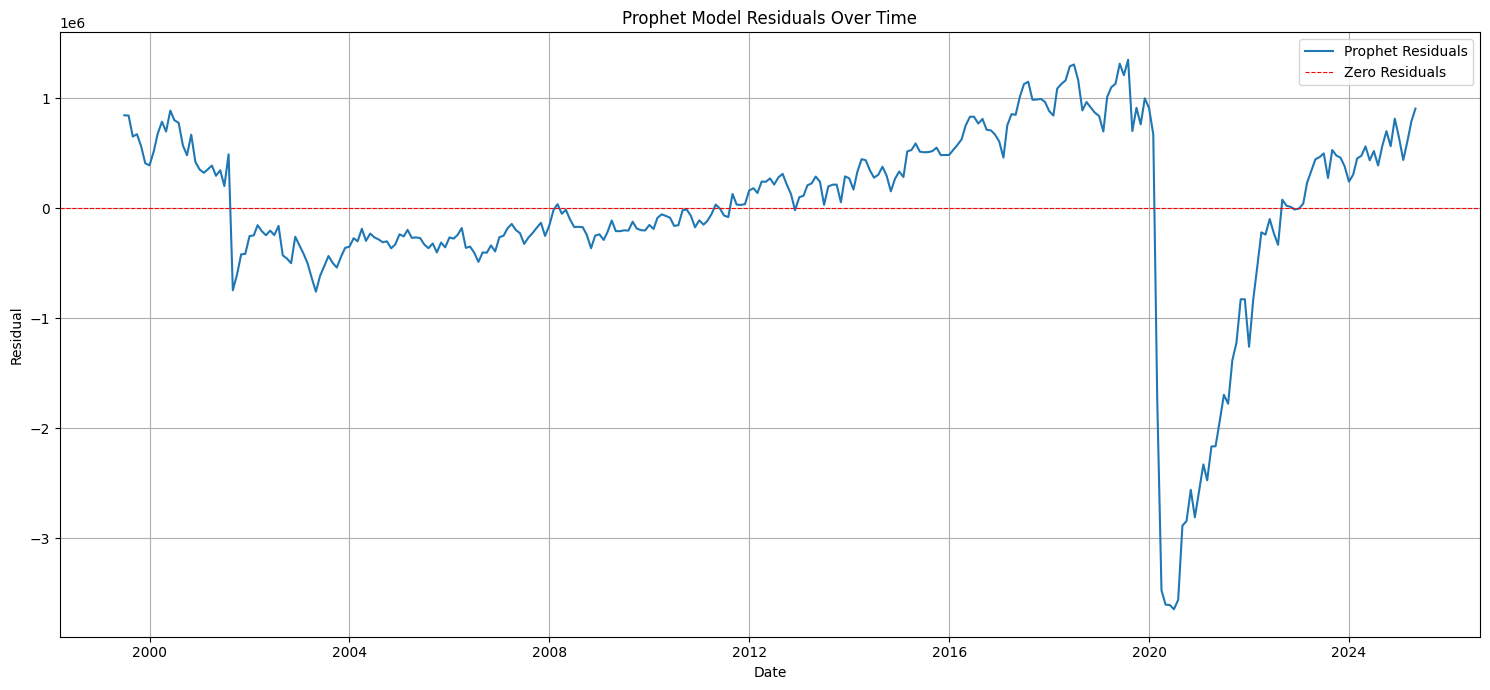

In [7]:
# Merge actuals with forecast to calculate residuals
prophet_results = pd.merge(
    prophet_df,
    forecast[['ds', 'yhat']],
    on='ds',
    how='left'
)

# Calculate residuals
prophet_results['residuals'] = prophet_results['y'] - prophet_results['yhat']

# Display residuals
print("Prophet Model Residuals (first 15 rows):")
display(prophet_results[['ds', 'y', 'yhat', 'residuals']].head(15))

# Plot residuals over time
plt.figure(figsize=(15, 7))
plt.plot(prophet_results['ds'], prophet_results['residuals'], label='Prophet Residuals')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Zero Residuals')
plt.title('Prophet Model Residuals Over Time')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Step C: Train an XGBoost Regressor on these residuals using lagged features (e.g., $t-1$, $t-12$).

XGBoost Residual Model MSE: 1270985408150.8306

XGBoost Predictions for Residuals (first 15 rows of test set):


,Actual Residual,Predicted Residual
ds,,
2020-06-01,-3.607707e+06,-3449145.00
2020-07-01,-3.645912e+06,-3461756.25
2020-08-01,-3.560332e+06,-3444199.75
2020-09-01,-2.885927e+06,-3452051.25
2020-10-01,-2.844598e+06,-3448055.50
2020-11-01,-2.560695e+06,-3454181.50
2020-12-01,-2.809882e+06,-3440345.00
2021-01-01,-2.570451e+06,-3543244.00
2021-02-01,-2.329450e+06,-3568426.00


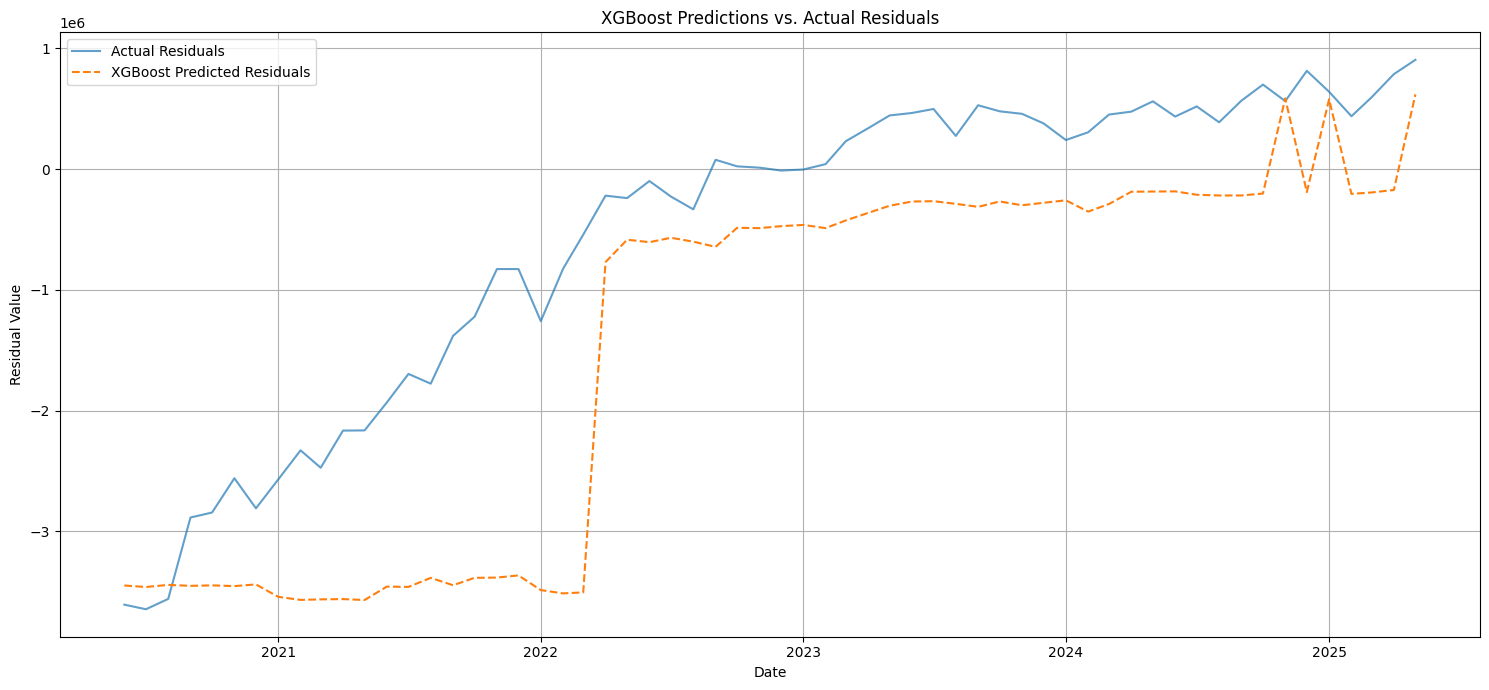

In [8]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Create features for XGBoost from residuals
# We will use the 'prophet_results' DataFrame
xgb_df = prophet_results.copy()
xgb_df = xgb_df.set_index('ds')

# Add lagged residual features (t-1 and t-12 are good starting points for monthly data)
xgb_df['residual_lag_1'] = xgb_df['residuals'].shift(1)
xgb_df['residual_lag_12'] = xgb_df['residuals'].shift(12)

# Add month and year as features
xgb_df['month'] = xgb_df.index.month
xgb_df['year'] = xgb_df.index.year

# Drop rows with NaN values resulting from lagging
xgb_df = xgb_df.dropna()

# Define features (X) and target (y)
X = xgb_df[['residual_lag_1', 'residual_lag_12', 'month', 'year']]
y = xgb_df['residuals']

# Split data into training and testing sets
# Use a time-series friendly split (e.g., train on earlier data, test on later data)
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Initialize and train XGBoost Regressor
xgboost_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
xgboost_model.fit(X_train, y_train)

# Make predictions on the test set
xgb_predictions = xgboost_model.predict(X_test)

# Evaluate XGBoost model
mse_xgboost = mean_squared_error(y_test, xgb_predictions)
print(f"XGBoost Residual Model MSE: {mse_xgboost}")

# Display the first few XGBoost predictions
print("\nXGBoost Predictions for Residuals (first 15 rows of test set):")
display(pd.DataFrame({'Actual Residual': y_test, 'Predicted Residual': xgb_predictions}, index=y_test.index).head(15))

# Plot actual vs predicted residuals
plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test, label='Actual Residuals', alpha=0.7)
plt.plot(y_test.index, xgb_predictions, label='XGBoost Predicted Residuals', linestyle='--')
plt.title('XGBoost Predictions vs. Actual Residuals')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Step D: Combine the predictions. This creates a model that understands both long-term cycles and short-term volatility.

Hybrid Model MSE (Prophet + XGBoost on Residuals): 1270985408150.8306

Hybrid Model Predictions (first 15 rows of test set):


,Actual,Prophet Forecast,XGBoost Residual Prediction,Hybrid Forecast
ds,,,,
2020-06-01,555119,4.162826e+06,-3449145.00,7.136813e+05
2020-07-01,765274,4.411186e+06,-3461756.25,9.494302e+05
2020-08-01,852578,4.412910e+06,-3444199.75,9.687106e+05
2020-09-01,905992,3.791919e+06,-3452051.25,3.398678e+05
2020-10-01,1073882,3.918480e+06,-3448055.50,4.704243e+05
2020-11-01,1052317,3.613012e+06,-3454181.50,1.588304e+05
2020-12-01,918723,3.728605e+06,-3440345.00,2.882603e+05
2021-01-01,769908,3.340359e+06,-3543244.00,-2.028854e+05
2021-02-01,736324,3.065774e+06,-3568426.00,-5.026520e+05


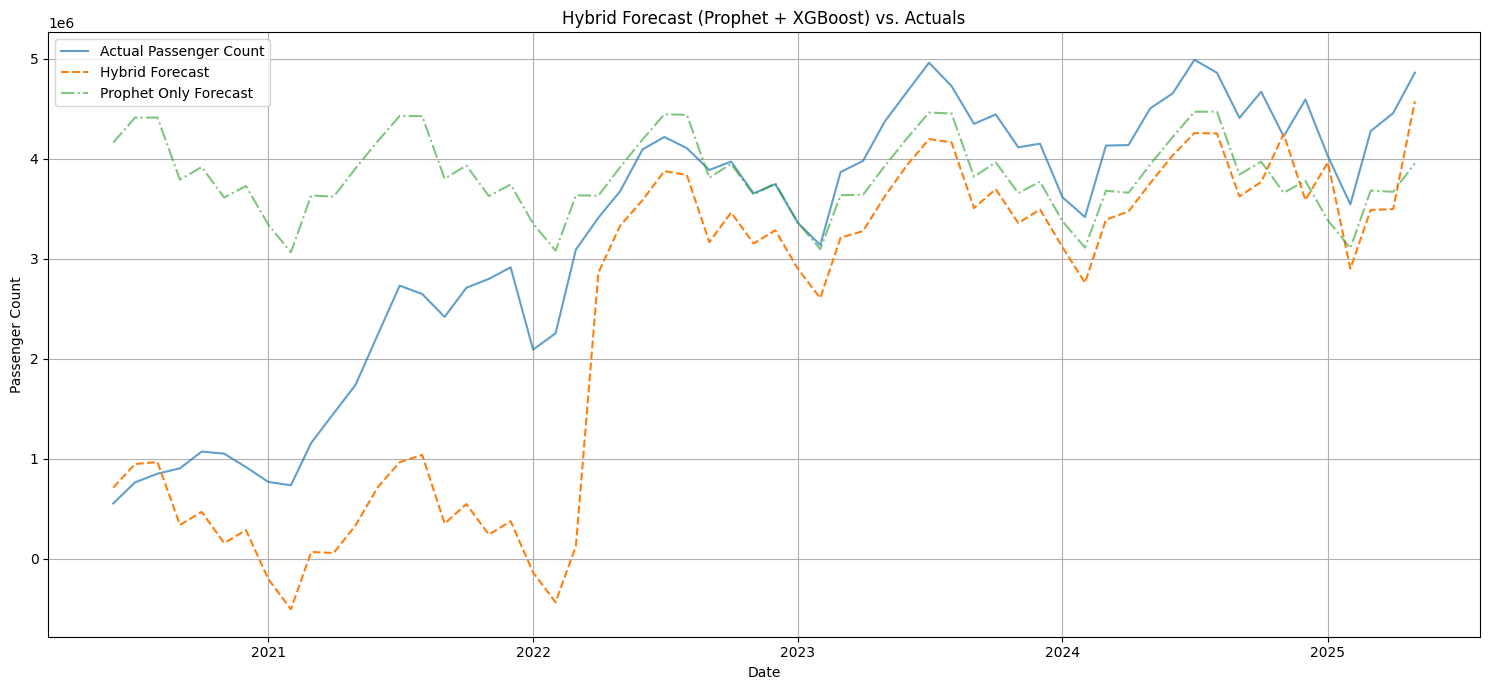

In [9]:
# Combine Prophet's forecast with XGBoost's residual predictions

# First, align the XGBoost predictions with the Prophet forecast dates in the test set
# Create a DataFrame for XGBoost predictions with correct 'ds' index
xgb_forecast_residuals = pd.DataFrame(xgb_predictions, index=X_test.index, columns=['xgb_residual_prediction'])

# Get Prophet's forecast for the test period
prophet_test_forecast = forecast[forecast['ds'].isin(X_test.index)].set_index('ds')

# Combine Prophet's yhat with XGBoost's residual predictions
hybrid_forecast_test = prophet_test_forecast['yhat'] + xgb_forecast_residuals['xgb_residual_prediction']

# Get actual values for the test period
actual_test_values = monthly_demand.loc[X_test.index]['Passenger Count']

# Evaluate the hybrid model
mse_hybrid = mean_squared_error(actual_test_values, hybrid_forecast_test)
print(f"Hybrid Model MSE (Prophet + XGBoost on Residuals): {mse_hybrid}")

# Display the first few hybrid predictions
print("\nHybrid Model Predictions (first 15 rows of test set):")
display(pd.DataFrame({
    'Actual': actual_test_values,
    'Prophet Forecast': prophet_test_forecast['yhat'],
    'XGBoost Residual Prediction': xgb_forecast_residuals['xgb_residual_prediction'],
    'Hybrid Forecast': hybrid_forecast_test
}).head(15))

# Plot actuals vs. hybrid forecast for the test period
plt.figure(figsize=(15, 7))
plt.plot(actual_test_values.index, actual_test_values, label='Actual Passenger Count', alpha=0.7)
plt.plot(hybrid_forecast_test.index, hybrid_forecast_test, label='Hybrid Forecast', linestyle='--')
plt.plot(prophet_test_forecast.index, prophet_test_forecast['yhat'], label='Prophet Only Forecast', linestyle='-.', alpha=0.6)
plt.title('Hybrid Forecast (Prophet + XGBoost) vs. Actuals')
plt.xlabel('Date')
plt.ylabel('Passenger Count')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

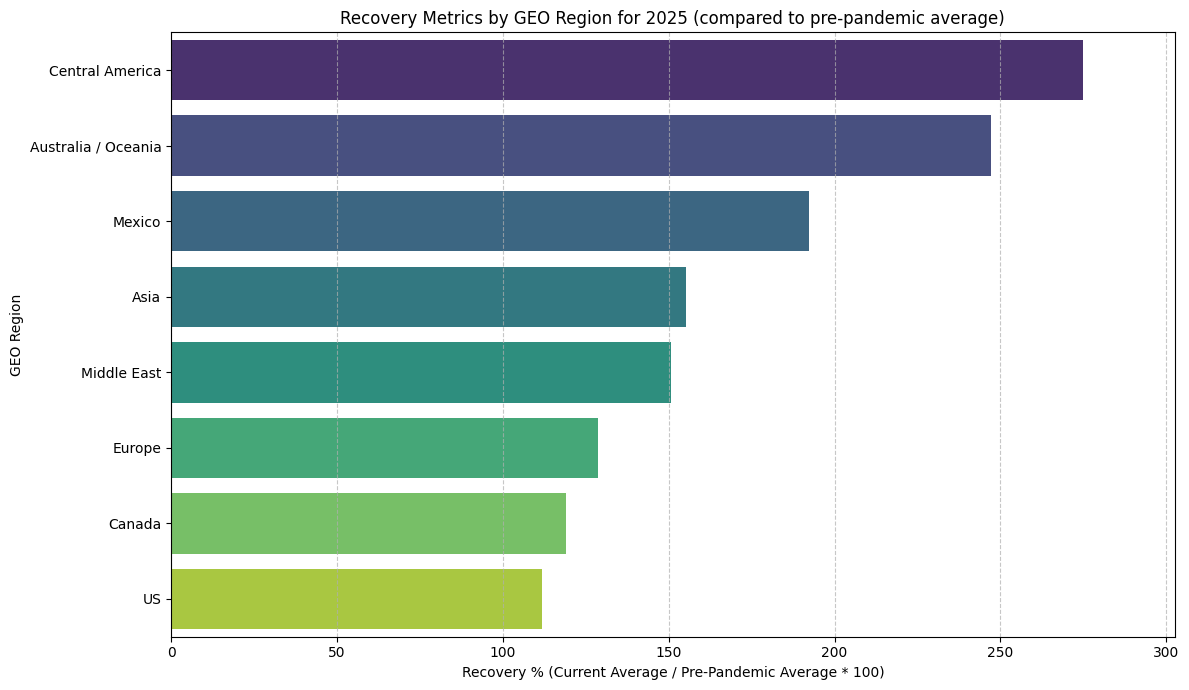

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Recovery %', y='GEO Region', data=recovery_df, palette='viridis', hue='GEO Region', legend=False)
plt.title(f'Recovery Metrics by GEO Region for {latest_year} (compared to pre-pandemic average)')
plt.xlabel('Recovery % (Current Average / Pre-Pandemic Average * 100)')
plt.ylabel('GEO Region')
plt.xlim(0, recovery_df['Recovery %'].max() * 1.1) # Set x-axis limit slightly above max recovery for better visualization
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Implement a Segmented Forecast by GEO Region

To analyze and visualize recovery trends across different geographical regions, I will perform the following steps:

1.  **Aggregate Monthly Data by Region**: Group the DataFrame by `GEO Region` and `Activity Period Start Date` to get the total monthly passenger count for each region.
2.  **Calculate Pre-Pandemic Baseline**: Determine a historical baseline for each region by calculating the average monthly passenger count during a pre-pandemic period (e.g., up to the end of 2019).
3.  **Visualize Regional Trends vs. Baseline**: Plot the monthly passenger counts for each region and overlay their respective pre-pandemic average. This will allow for a visual assessment of recovery relative to historical trends.
4.  **Calculate Recovery Metric**: Compute a recovery metric (e.g., percentage recovery relative to pre-pandemic levels) for more recent periods to quantify and compare recovery rates across regions.

Pre-Pandemic Monthly Average Passenger Count by Region:
Asia: 346,334
Australia / Oceania: 35,652
Canada: 109,311
Central America: 12,888
Europe: 222,026
Mexico: 65,940
Middle East: 28,182
South America: 5,453
US: 2,670,882


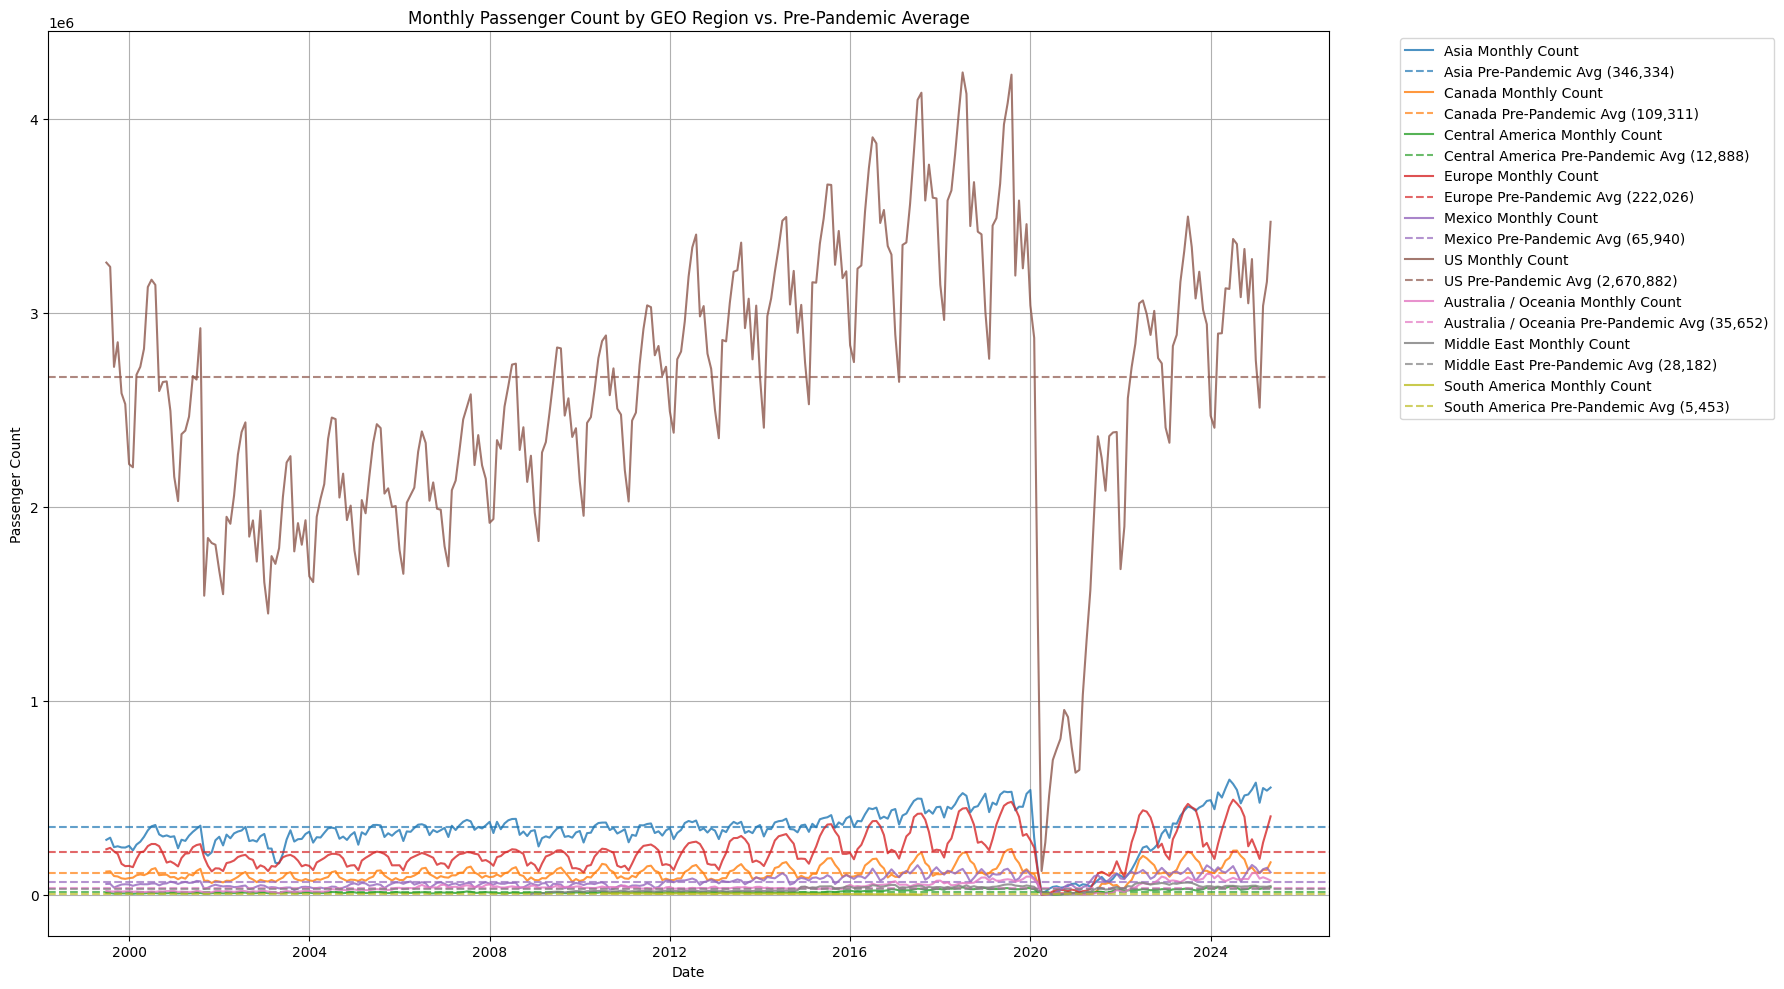


Recovery Metrics for 2025 (compared to pre-pandemic average):


,GEO Region,Current Average,Pre-Pandemic Average,Recovery %
3,Central America,35442.0,1.288770e+04,275.006419
1,Australia / Oceania,88170.0,3.565230e+04,247.305217
5,Mexico,126834.8,6.593998e+04,192.348861
0,Asia,537865.2,3.463344e+05,155.302268
6,Middle East,42461.2,2.818247e+04,150.665310
4,Europe,285856.4,2.220264e+05,128.748808
2,Canada,130006.8,1.093108e+05,118.933169
7,US,2986559.0,2.670882e+06,111.819198


In [11]:
import matplotlib.pyplot as plt

# 1. Aggregate Monthly Data by Region
monthly_regional_demand = df.groupby(['GEO Region', 'Activity Period Start Date'])['Passenger Count'].sum().reset_index()

# Set 'Activity Period Start Date' as index and sort
monthly_regional_demand = monthly_regional_demand.set_index('Activity Period Start Date').sort_index()

# 2. Calculate Pre-Pandemic Baseline (e.g., average monthly passenger count up to end of 2019)
pre_pandemic_end_date = '2019-12-31'
pre_pandemic_demand = monthly_regional_demand[monthly_regional_demand.index <= pre_pandemic_end_date]

# Calculate mean passenger count for each region in the pre-pandemic period
pre_pandemic_avg = pre_pandemic_demand.groupby('GEO Region')['Passenger Count'].mean().to_dict()
print("Pre-Pandemic Monthly Average Passenger Count by Region:")
for region, avg_count in pre_pandemic_avg.items():
    print(f"{region}: {avg_count:,.0f}")

# 3. Visualize Regional Trends vs. Baseline
plt.figure(figsize=(18, 10))

for region in monthly_regional_demand['GEO Region'].unique():
    region_data = monthly_regional_demand[monthly_regional_demand['GEO Region'] == region]
    plt.plot(region_data.index, region_data['Passenger Count'], label=f'{region} Monthly Count', alpha=0.8)

    # Plot pre-pandemic average as a horizontal line
    if region in pre_pandemic_avg:
        plt.axhline(y=pre_pandemic_avg[region], color=plt.gca().lines[-1].get_color(), linestyle='--', alpha=0.7,
                    label=f'{region} Pre-Pandemic Avg ({pre_pandemic_avg[region]:,.0f})')

plt.title('Monthly Passenger Count by GEO Region vs. Pre-Pandemic Average')
plt.xlabel('Date')
plt.ylabel('Passenger Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Calculate Recovery Metric (e.g., for the most recent year in the data)
# Assuming data goes up to 2024 or latest available
latest_year = monthly_regional_demand.index.max().year
recovery_period_demand = monthly_regional_demand[monthly_regional_demand.index.year == latest_year]

recovery_metrics = []
for region, avg_count in pre_pandemic_avg.items():
    current_avg = recovery_period_demand[recovery_period_demand['GEO Region'] == region]['Passenger Count'].mean()
    if not pd.isna(current_avg) and avg_count > 0:
        recovery_percentage = (current_avg / avg_count) * 100
        recovery_metrics.append({'GEO Region': region, 'Current Average': current_avg, 'Pre-Pandemic Average': avg_count, 'Recovery %': recovery_percentage})

recovery_df = pd.DataFrame(recovery_metrics).sort_values(by='Recovery %', ascending=False)
print(f"\nRecovery Metrics for {latest_year} (compared to pre-pandemic average):")
display(recovery_df)

Hybrid Model MSE (Prophet + XGBoost on Residuals): 1270985408150.8306

Hybrid Model Predictions (first 15 rows of test set):


,Actual,Prophet Forecast,XGBoost Residual Prediction,Hybrid Forecast
ds,,,,
2020-06-01,555119,4.162826e+06,-3449145.00,7.136813e+05
2020-07-01,765274,4.411186e+06,-3461756.25,9.494302e+05
2020-08-01,852578,4.412910e+06,-3444199.75,9.687106e+05
2020-09-01,905992,3.791919e+06,-3452051.25,3.398678e+05
2020-10-01,1073882,3.918480e+06,-3448055.50,4.704243e+05
2020-11-01,1052317,3.613012e+06,-3454181.50,1.588304e+05
2020-12-01,918723,3.728605e+06,-3440345.00,2.882603e+05
2021-01-01,769908,3.340359e+06,-3543244.00,-2.028854e+05
2021-02-01,736324,3.065774e+06,-3568426.00,-5.026520e+05


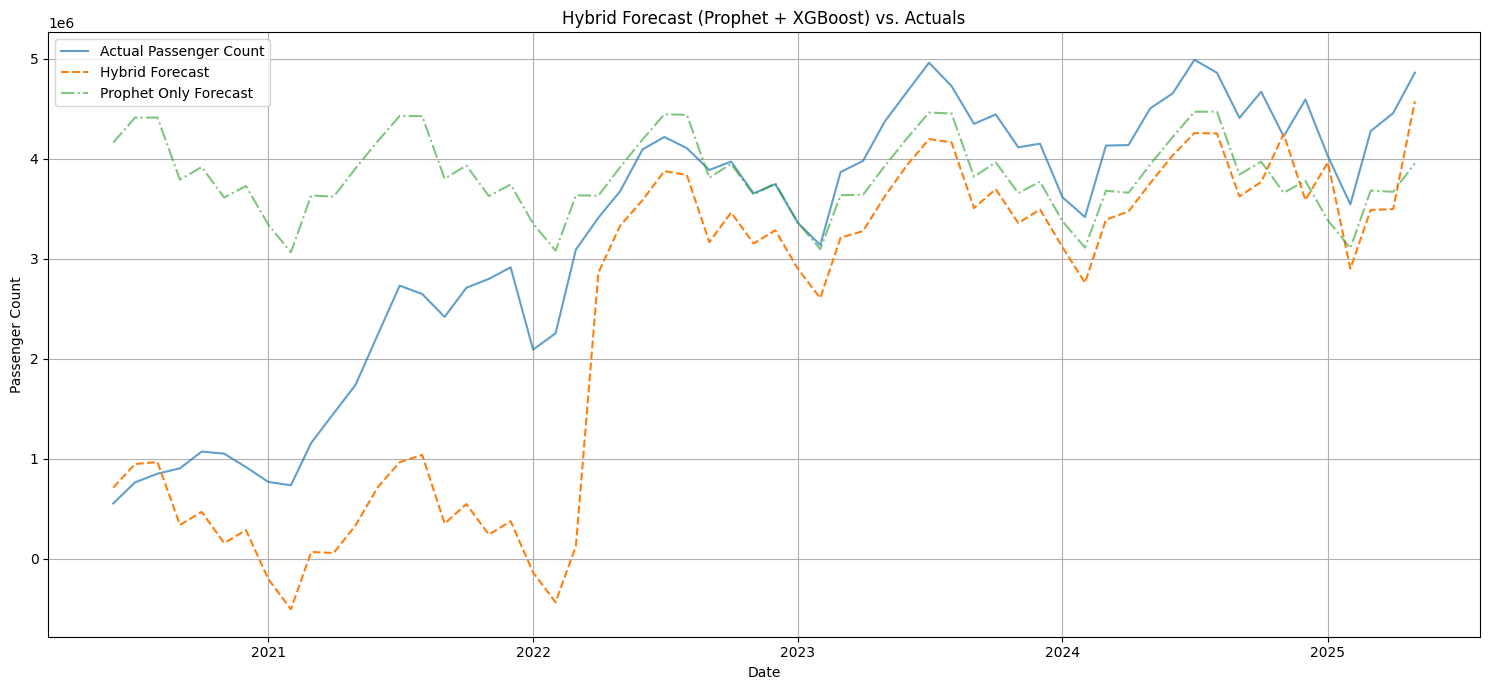

In [13]:
# Combine Prophet's forecast with XGBoost's residual predictions

# First, align the XGBoost predictions with the Prophet forecast dates in the test set
# Create a DataFrame for XGBoost predictions with correct 'ds' index
xgb_forecast_residuals = pd.DataFrame(xgb_predictions, index=X_test.index, columns=['xgb_residual_prediction'])

# Get Prophet's forecast for the test period
prophet_test_forecast = forecast[forecast['ds'].isin(X_test.index)].set_index('ds')

# Combine Prophet's yhat with XGBoost's residual predictions
hybrid_forecast_test = prophet_test_forecast['yhat'] + xgb_forecast_residuals['xgb_residual_prediction']

# Get actual values for the test period
actual_test_values = monthly_demand.loc[X_test.index]['Passenger Count']

# Evaluate the hybrid model
mse_hybrid = mean_squared_error(actual_test_values, hybrid_forecast_test)
print(f"Hybrid Model MSE (Prophet + XGBoost on Residuals): {mse_hybrid}")

# Display the first few hybrid predictions
print("\nHybrid Model Predictions (first 15 rows of test set):")
display(pd.DataFrame({
    'Actual': actual_test_values,
    'Prophet Forecast': prophet_test_forecast['yhat'],
    'XGBoost Residual Prediction': xgb_forecast_residuals['xgb_residual_prediction'],
    'Hybrid Forecast': hybrid_forecast_test
}).head(15))

# Plot actuals vs. hybrid forecast for the test period
plt.figure(figsize=(15, 7))
plt.plot(actual_test_values.index, actual_test_values, label='Actual Passenger Count', alpha=0.7)
plt.plot(hybrid_forecast_test.index, hybrid_forecast_test, label='Hybrid Forecast', linestyle='--')
plt.plot(prophet_test_forecast.index, prophet_test_forecast['yhat'], label='Prophet Only Forecast', linestyle='-.', alpha=0.6)
plt.title('Hybrid Forecast (Prophet + XGBoost) vs. Actuals')
plt.xlabel('Date')
plt.ylabel('Passenger Count')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### External Feature Integration: Low Fare vs. Other Passenger Ratio

To capture the 'budget-to-premium' shift as a leading indicator of demand changes, I will calculate the monthly ratio of 'Low Fare' passengers to 'Other' passengers. This involves several steps:

1.  **Filter Data:** Select only the rows corresponding to 'Low Fare' and 'Other' `Price Category Code`.
2.  **Aggregate Monthly Counts:** Group the filtered data by `Activity Period Start Date` and `Price Category Code` to sum the `Passenger Count` for each category per month.
3.  **Pivot Table:** Reshape the aggregated data to have `Low Fare` and `Other` passenger counts as separate columns for each month.
4.  **Calculate Ratio:** Compute the ratio of 'Low Fare' passenger count to 'Other' passenger count.
5.  **Visualize Trend:** Plot this ratio over time to observe its evolution.

Monthly Low Fare vs. Other Passenger Ratio (first 15 rows):


Price Category Code,Low Fare,Other,Low_Fare_to_Other_Ratio
Activity Period Start Date,,,
1999-07-01,232920,3743826,0.062214
1999-08-01,237611,3735083,0.063616
1999-09-01,187417,3154547,0.059412
1999-10-01,191218,3277628,0.058340
1999-11-01,191223,2954017,0.064733
1999-12-01,175765,2901377,0.060580
2000-01-01,162654,2618475,0.062118
2000-02-01,168536,2556857,0.065915
2000-03-01,201484,3092545,0.065152


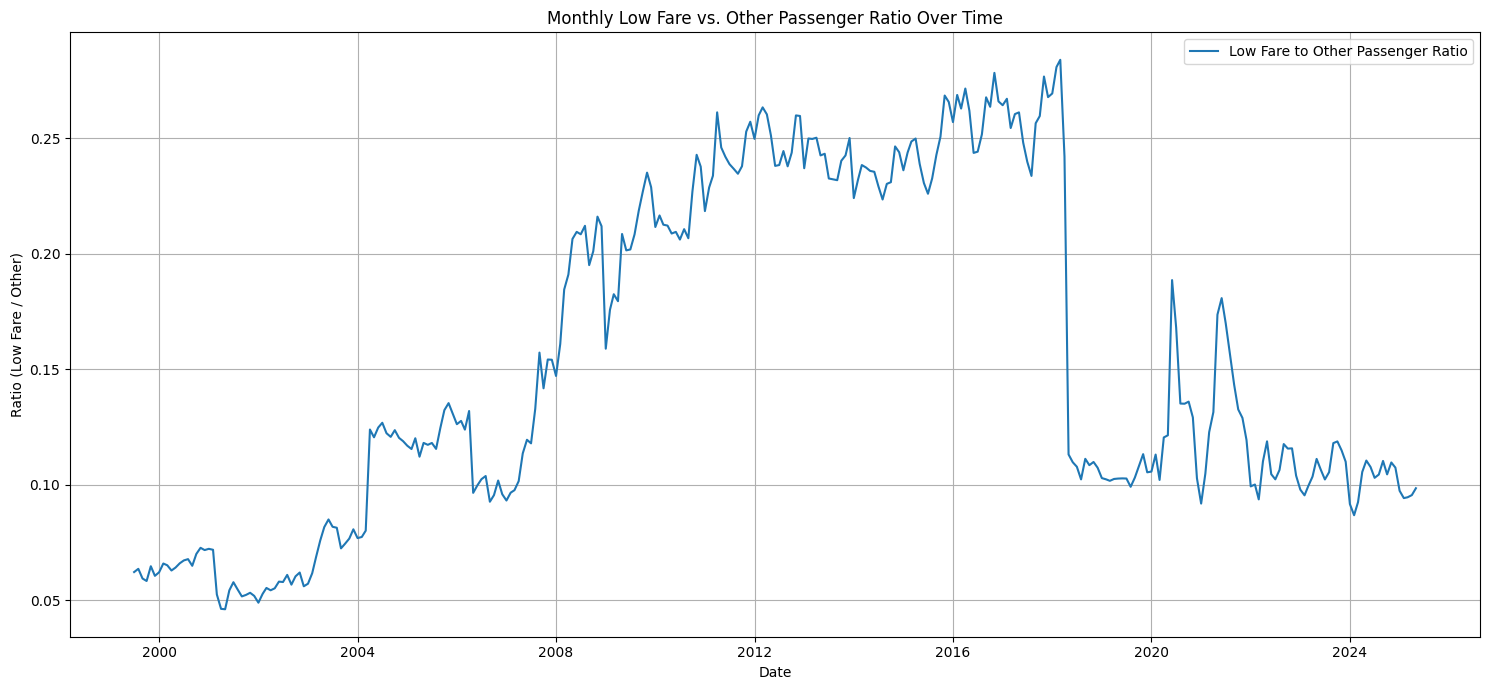

In [14]:
import matplotlib.pyplot as plt

# 1. Filter for 'Low Fare' and 'Other' price categories
price_category_df = df[df['Price Category Code'].isin(['Low Fare', 'Other'])].copy()

# 2. Aggregate monthly passenger counts for these categories
monthly_price_category_counts = price_category_df.groupby(['Activity Period Start Date', 'Price Category Code'])['Passenger Count'].sum().reset_index()

# 3. Pivot the table to get 'Low Fare' and 'Other' as separate columns
price_category_pivot = monthly_price_category_counts.pivot(index='Activity Period Start Date', columns='Price Category Code', values='Passenger Count').fillna(0)

# Ensure both 'Low Fare' and 'Other' columns exist, filling with 0 if not present for a month
if 'Low Fare' not in price_category_pivot.columns:
    price_category_pivot['Low Fare'] = 0
if 'Other' not in price_category_pivot.columns:
    price_category_pivot['Other'] = 0

# 4. Calculate the ratio: Low Fare vs. Other
# Add a small epsilon to the denominator to avoid division by zero
epsilon = 1e-6
price_category_pivot['Low_Fare_to_Other_Ratio'] = price_category_pivot['Low Fare'] / (price_category_pivot['Other'] + epsilon)

# Display the first few rows of the new feature
print("Monthly Low Fare vs. Other Passenger Ratio (first 15 rows):")
display(price_category_pivot.head(15))

# 5. Visualize the trend of the ratio
plt.figure(figsize=(15, 7))
plt.plot(price_category_pivot.index, price_category_pivot['Low_Fare_to_Other_Ratio'], label='Low Fare to Other Passenger Ratio')
plt.title('Monthly Low Fare vs. Other Passenger Ratio Over Time')
plt.xlabel('Date')
plt.ylabel('Ratio (Low Fare / Other)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

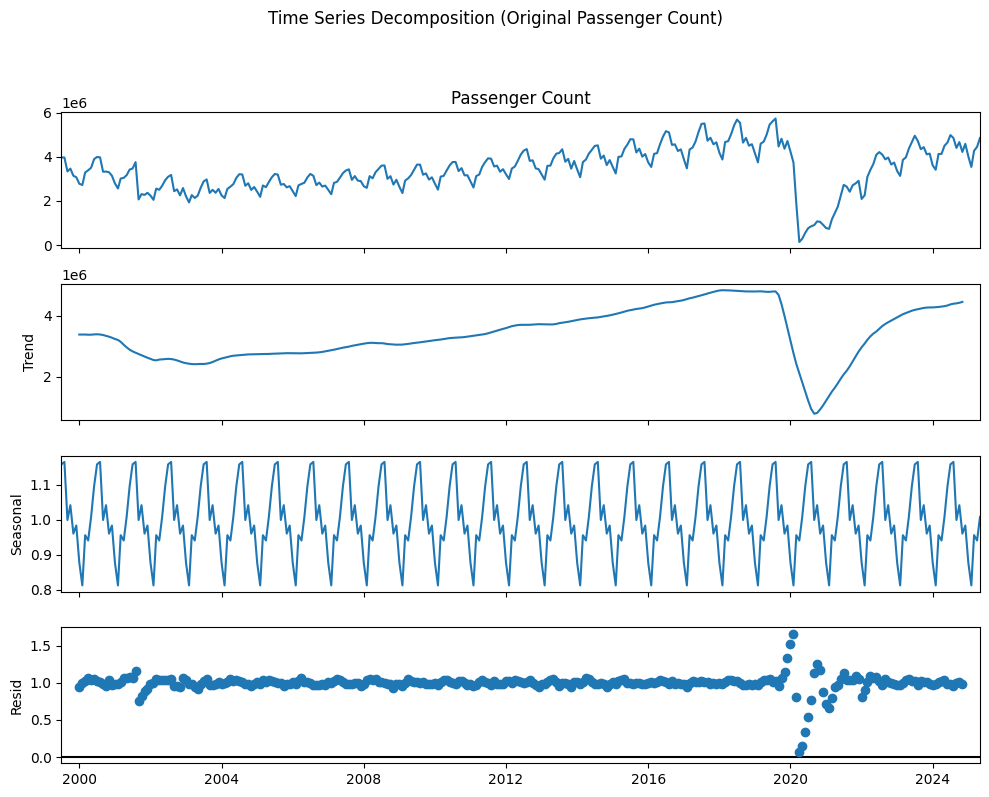

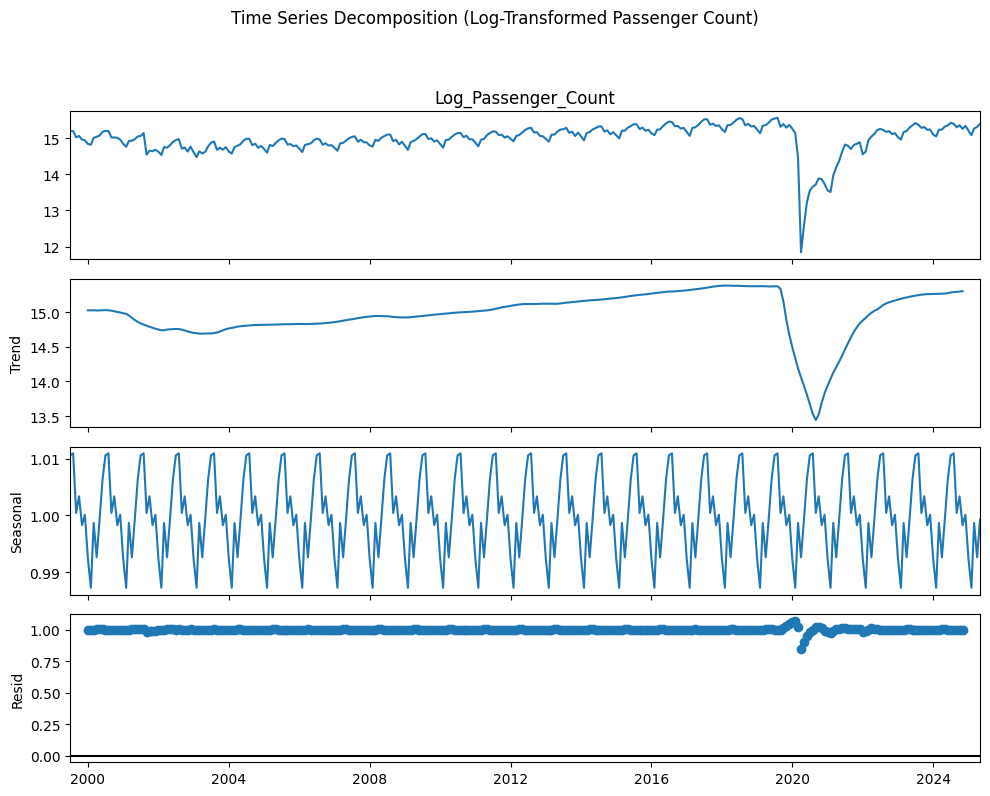

In [16]:
import statsmodels.api as sm
import numpy as np # Import numpy

# Perform seasonal decomposition on the original Passenger Count
# Given the plot, seasonal swings appear to grow with the level, suggesting a multiplicative model.
# Use period=12 for monthly data
decomposition_original = sm.tsa.seasonal_decompose(monthly_demand['Passenger Count'], model='multiplicative', period=12)

# Plot the decomposed components for the original series
fig_original = decomposition_original.plot()
fig_original.set_size_inches(10, 8)
fig_original.suptitle('Time Series Decomposition (Original Passenger Count)', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# Apply Log Transformation to stabilize variance
monthly_demand['Log_Passenger_Count'] = monthly_demand['Passenger Count'].apply(lambda x: pd.NA if x <= 0 else x).map(lambda x: float(x) if pd.notna(x) else pd.NA)
monthly_demand['Log_Passenger_Count'] = monthly_demand['Log_Passenger_Count'].dropna().apply(lambda x: pd.NA if x <= 0 else x).apply(lambda x: float(x) if pd.notna(x) else pd.NA).apply(lambda x: np.log(x) if pd.notna(x) else pd.NA)



# Perform seasonal decomposition on the Log-transformed Passenger Count
decomposition_log = sm.tsa.seasonal_decompose(monthly_demand['Log_Passenger_Count'].dropna(), model='multiplicative', period=12)

# Plot the decomposed components for the log-transformed series
fig_log = decomposition_log.plot()
fig_log.set_size_inches(10, 8)
fig_log.suptitle('Time Series Decomposition (Log-Transformed Passenger Count)', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Now, let's aggregate the `Passenger Count` by `Activity Period Start Date` to get a monthly time series, and then perform a rolling window analysis for 3-month and 12-month periods to visualize demand trends and volatility.

Monthly Demand with Rolling Statistics:


,Passenger Count,3_month_rolling_mean,3_month_rolling_std,12_month_rolling_mean,12_month_rolling_std
Activity Period Start Date,,,,,
1999-07-01,3976746,NaN,NaN,NaN,NaN
1999-08-01,3972694,NaN,NaN,NaN,NaN
1999-09-01,3341964,3.763801e+06,365327.464778,NaN,NaN
1999-10-01,3468846,3.594501e+06,333612.095586,NaN,NaN
1999-11-01,3145240,3.318683e+06,163054.294299,NaN,NaN
1999-12-01,3077142,3.230409e+06,209280.594918,NaN,NaN
2000-01-01,2781129,3.001170e+06,193579.378247,NaN,NaN
2000-02-01,2725393,2.861221e+06,189057.996774,NaN,NaN
2000-03-01,3294029,2.933517e+06,313453.827592,NaN,NaN


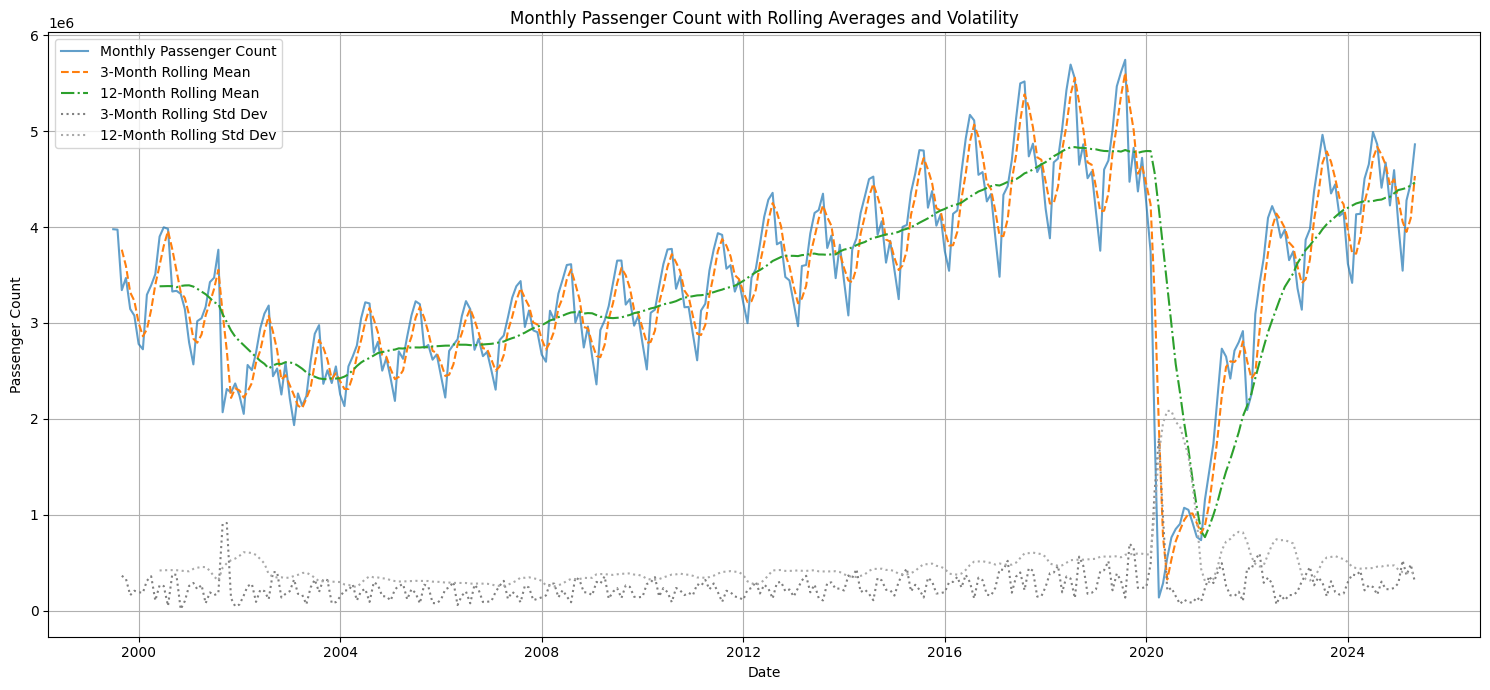

In [17]:
import matplotlib.pyplot as plt

# Aggregate Passenger Count by Activity Period Start Date (monthly time series)
monthly_demand = df.groupby('Activity Period Start Date')['Passenger Count'].sum().reset_index()
monthly_demand = monthly_demand.set_index('Activity Period Start Date').sort_index()

# Calculate 3-month rolling mean and standard deviation
monthly_demand['3_month_rolling_mean'] = monthly_demand['Passenger Count'].rolling(window=3).mean()
monthly_demand['3_month_rolling_std'] = monthly_demand['Passenger Count'].rolling(window=3).std()

# Calculate 12-month rolling mean and standard deviation
monthly_demand['12_month_rolling_mean'] = monthly_demand['Passenger Count'].rolling(window=12).mean()
monthly_demand['12_month_rolling_std'] = monthly_demand['Passenger Count'].rolling(window=12).std()

# Display the first few rows of the monthly demand with rolling statistics
print("Monthly Demand with Rolling Statistics:")
display(monthly_demand.head(15))

# Visualize the rolling window analysis
plt.figure(figsize=(15, 7))

# Plot Passenger Count and rolling means
plt.plot(monthly_demand['Passenger Count'], label='Monthly Passenger Count', alpha=0.7)
plt.plot(monthly_demand['3_month_rolling_mean'], label='3-Month Rolling Mean', linestyle='--')
plt.plot(monthly_demand['12_month_rolling_mean'], label='12-Month Rolling Mean', linestyle='-.')

# Plot rolling standard deviations
plt.plot(monthly_demand['3_month_rolling_std'], label='3-Month Rolling Std Dev', linestyle=':', color='gray')
plt.plot(monthly_demand['12_month_rolling_std'], label='12-Month Rolling Std Dev', linestyle=':', color='darkgray')

plt.title('Monthly Passenger Count with Rolling Averages and Volatility')
plt.xlabel('Date')
plt.ylabel('Passenger Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()